# 👷 Astoria Dry Cleaning — Workforce Planning
**Deliverable: Service-Based Demand Analysis**

Analyses `astoria_orders.csv` across 10 sections:
1. Setup & Load Data
2. Effort Score Overview
3. Service Workload Ranking
4. Category: Workload vs Revenue
5. Processing Time Analysis
6. Express Order Pressure
7. Weekly Workload Forecast
8. Day-of-Week Patterns
9. Technician Allocation
10. Key Insights & Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

EFFORT_COLOURS = {1:'#4CAF50', 2:'#8BC34A', 3:'#FFC107', 4:'#FF5722', 5:'#B71C1C'}
CAT_PALETTE    = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4','#E91E63','#795548']
TECH_COLOURS   = {
    'General Technician': '#4CAF50',
    'Express Handler':    '#FF9800',
    'Skilled Technician': '#2196F3',
    'Senior Specialist':  '#B71C1C',
}

print('Libraries loaded OK')

Libraries loaded OK


## 1. Load & Prepare Data

In [2]:
# Update path if your CSV is in a different folder
df = pd.read_csv('../../data1/astoria_orders.csv')

# Parse dates
for col in ['booking_date', 'collection_date', 'delivery_date']:
    df[col] = pd.to_datetime(df[col])

# Derived columns
df['booking_week']    = df['booking_date'].dt.isocalendar().week.astype(int)
df['booking_month']   = df['booking_date'].dt.month
df['booking_year']    = df['booking_date'].dt.year
df['is_express']      = df['express_type'].notna()
df['is_delicate']     = df['delicate_surcharge'] > 0
df['total_effort']    = df['effort_score'] * df['quantity']
df['effort_tier']     = df['effort_score'].map({
    1: 'Tier 1 - Basic',
    2: 'Tier 2 - Standard',
    3: 'Tier 3 - Moderate',
    4: 'Tier 4 - Complex',
    5: 'Tier 5 - Premium',
})

def assign_tech(row):
    if row['effort_score'] >= 4:
        return 'Senior Specialist'
    elif row['effort_score'] == 3 or row['processing_days'] >= 7:
        return 'Skilled Technician'
    elif row['is_express']:
        return 'Express Handler'
    else:
        return 'General Technician'

df['tech_type'] = df.apply(assign_tech, axis=1)

print(f'Rows         : {len(df):,}')
print(f'Date range   : {df.booking_date.min().date()} to {df.booking_date.max().date()}')
print(f'Services     : {df.service.nunique()} unique')
print(f'Express orders: {df.is_express.sum():,} ({df.is_express.mean()*100:.1f}%)')
print(f'Delicate orders: {df.is_delicate.sum():,} ({df.is_delicate.mean()*100:.1f}%)')
df.head(3)

Rows         : 5,000
Date range   : 2024-01-01 to 2025-06-27
Services     : 45 unique
Express orders: 1,290 (25.8%)
Delicate orders: 209 (4.2%)


,order_id,booking_date,booking_time,booking_hour,booking_day_of_week,collection_date,collection_time,delivery_date,delivery_slot,zone,...,effort_score,order_status,booking_week,booking_month,booking_year,is_express,is_delicate,total_effort,effort_tier,tech_type
0,AST-00001,2024-06-07,11:15,11,Friday,2024-06-07,14:46,2024-06-10,15:00-18:00,Choa Chu Kang / Bukit Panjang,...,1,Completed,23,6,2024,False,False,1,Tier 1 - Basic,General Technician
1,AST-00002,2024-03-23,11:24,11,Saturday,2024-03-23,16:07,2024-03-25,15:00-18:00,Buona Vista / Holland,...,2,Completed,12,3,2024,False,False,4,Tier 2 - Standard,General Technician
2,AST-00003,2024-04-19,10:08,10,Friday,2024-04-19,15:55,2024-04-22,12:00-16:00,Choa Chu Kang / Bukit Panjang,...,2,Completed,16,4,2024,True,False,6,Tier 2 - Standard,Express Handler


## 2. Effort Score Overview
Effort scores range from **1 (basic press)** to **5 (luxury/restoration)**. 
This section shows how orders, workload, and revenue are distributed across tiers.

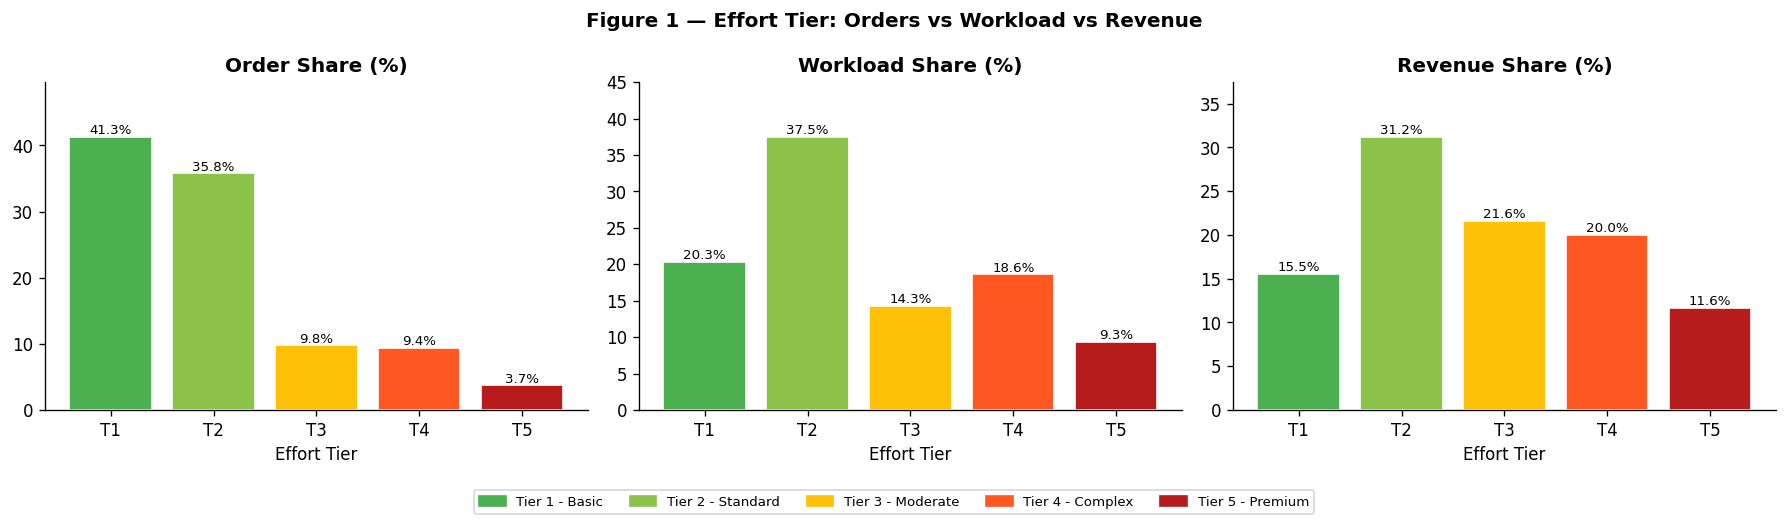

      effort_tier  orders  order_pct  total_workload  workload_pct   revenue  revenue_pct  avg_proc_days
   Tier 1 - Basic    2067       41.3            4187          20.3  61658.55         15.5       1.927431
Tier 2 - Standard    1789       35.8            7742          37.5 123816.90         31.2       3.017328
Tier 3 - Moderate     489        9.8            2961          14.3  85855.28         21.6       3.736196
 Tier 4 - Complex     471        9.4            3836          18.6  79569.54         20.0       7.373673
 Tier 5 - Premium     184        3.7            1925           9.3  46087.80         11.6      10.195652


In [3]:
effort_summary = (
    df.groupby(['effort_score', 'effort_tier'])
    .agg(
        orders         = ('order_id',        'count'),
        total_workload = ('total_effort',     'sum'),
        revenue        = ('order_value_sgd',  'sum'),
        avg_proc_days  = ('processing_days',  'mean'),
    )
    .reset_index()
)
effort_summary['order_pct']    = (effort_summary['orders']         / effort_summary['orders'].sum()         * 100).round(1)
effort_summary['workload_pct'] = (effort_summary['total_workload'] / effort_summary['total_workload'].sum() * 100).round(1)
effort_summary['revenue_pct']  = (effort_summary['revenue']        / effort_summary['revenue'].sum()        * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
short_labels = [f'T{s}' for s in effort_summary['effort_score']]
colours      = [EFFORT_COLOURS[s] for s in effort_summary['effort_score']]

for ax, col, title in [
    (axes[0], 'order_pct',    'Order Share (%)'),
    (axes[1], 'workload_pct', 'Workload Share (%)'),
    (axes[2], 'revenue_pct',  'Revenue Share (%)'),
]:
    bars = ax.bar(short_labels, effort_summary[col], color=colours, edgecolor='white')
    for bar, v in zip(bars, effort_summary[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{v}%', ha='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Effort Tier')
    ax.set_ylim(0, effort_summary[col].max() * 1.2)

patches = [mpatches.Patch(color=EFFORT_COLOURS[r['effort_score']], label=r['effort_tier'])
           for _, r in effort_summary.iterrows()]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Figure 1 — Effort Tier: Orders vs Workload vs Revenue', fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_effort_overview.png', bbox_inches='tight')
plt.show()

print(effort_summary[['effort_tier','orders','order_pct','total_workload','workload_pct','revenue','revenue_pct','avg_proc_days']].to_string(index=False))

## 3. Service Workload Ranking
Rank every service by **total workload units** (effort_score × quantity).

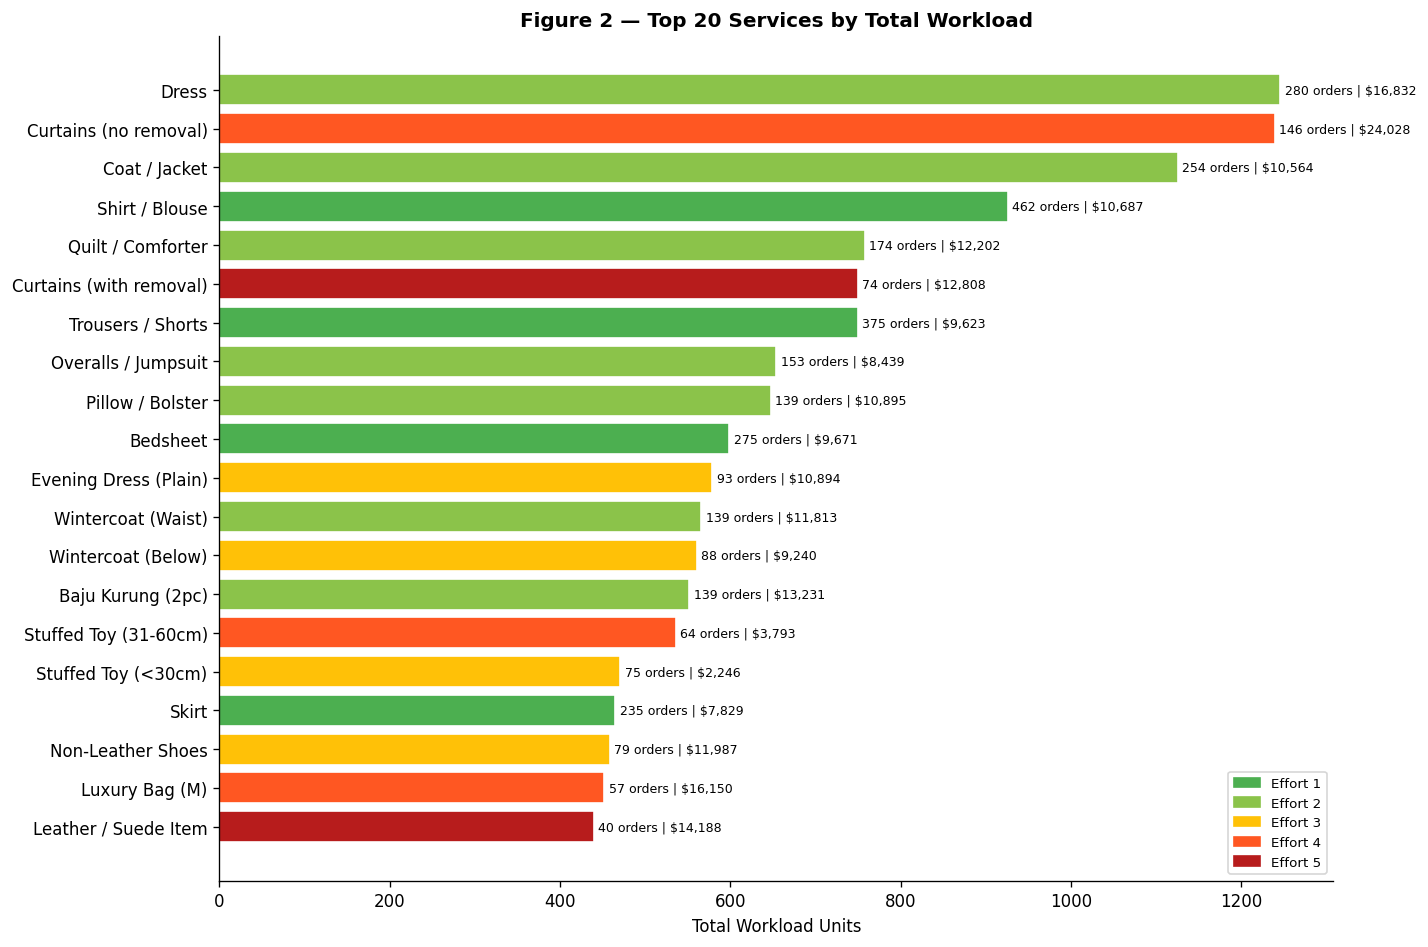

In [4]:
svc_summary = (
    df.groupby(['service', 'category', 'effort_score'])
    .agg(
        orders         = ('order_id',       'count'),
        total_workload = ('total_effort',    'sum'),
        revenue        = ('order_value_sgd', 'sum'),
        avg_proc_days  = ('processing_days', 'mean'),
    )
    .reset_index()
    .sort_values('total_workload', ascending=False)
)

top20 = svc_summary.head(20)
bar_colors = [EFFORT_COLOURS[s] for s in top20['effort_score']]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20['service'], top20['total_workload'], color=bar_colors, edgecolor='white')
for bar, (_, row) in zip(bars, top20.iterrows()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{row['orders']} orders | ${row['revenue']:,.0f}",
            va='center', fontsize=7.5)
ax.set_xlabel('Total Workload Units')
ax.set_title('Figure 2 — Top 20 Services by Total Workload', fontweight='bold')
ax.invert_yaxis()

patches = [mpatches.Patch(color=EFFORT_COLOURS[i], label=f'Effort {i}') for i in range(1, 6)]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.savefig('fig2_service_workload.png', bbox_inches='tight')
plt.show()

## 4. Category: Workload vs Revenue
Are high-effort categories generating proportional revenue? 
Categories **below** the average revenue-per-workload-unit line may need pricing review.

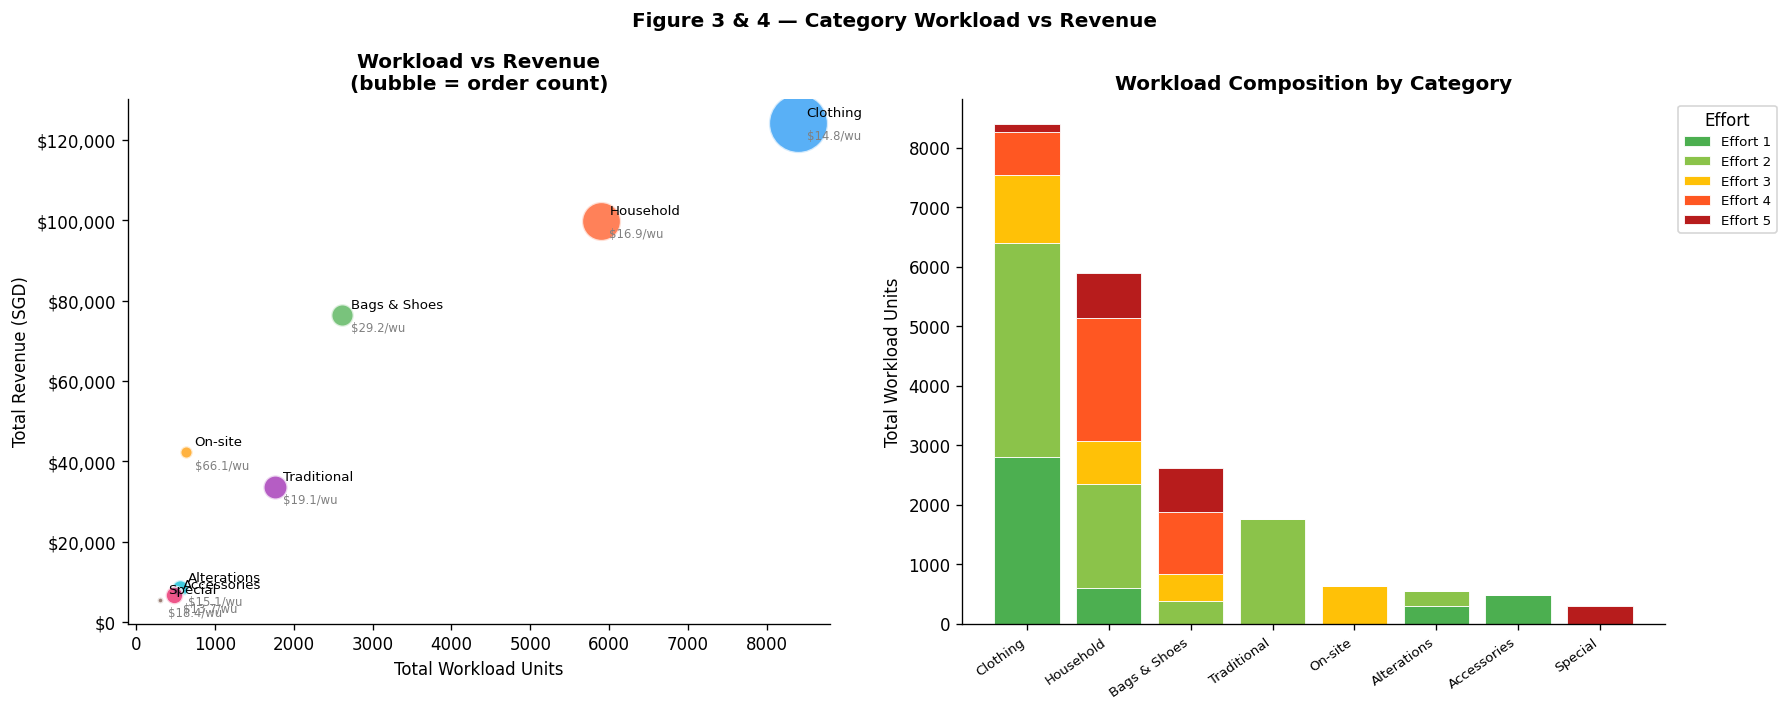

    category  orders  total_workload  workload_pct   revenue  revenue_pct  revenue_per_wu  avg_proc_days
    Clothing    2528            8397          40.7 124287.34         31.3           14.80       2.558149
   Household    1107            5896          28.6  99847.60         25.2           16.93       5.317073
Bags & Shoes     368            2616          12.7  76414.44         19.2           29.21       5.315217
 Traditional     425            1760           8.5  33622.32          8.5           19.10       3.000000
     On-site     114             639           3.1  42244.68         10.6           66.11       0.000000
 Alterations     204             554           2.7   8380.42          2.1           15.13       1.264706
 Accessories     228             489           2.4   6679.28          1.7           13.66       2.000000
     Special      26             300           1.5   5511.99          1.4           18.37      10.000000


In [5]:
cat_summary = (
    df.groupby('category')
    .agg(
        orders         = ('order_id',       'count'),
        total_workload = ('total_effort',    'sum'),
        revenue        = ('order_value_sgd', 'sum'),
        avg_effort     = ('effort_score',    'mean'),
        avg_proc_days  = ('processing_days', 'mean'),
    )
    .reset_index()
    .sort_values('total_workload', ascending=False)
)
cat_summary['revenue_per_wu'] = (cat_summary['revenue'] / cat_summary['total_workload']).round(2)
cat_summary['workload_pct']   = (cat_summary['total_workload'] / cat_summary['total_workload'].sum() * 100).round(1)
cat_summary['revenue_pct']    = (cat_summary['revenue']        / cat_summary['revenue'].sum()        * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bubble chart
ax = axes[0]
for i, (_, row) in enumerate(cat_summary.iterrows()):
    ax.scatter(row['total_workload'], row['revenue'],
               s=row['orders'] * 0.5, color=CAT_PALETTE[i % len(CAT_PALETTE)],
               alpha=0.75, edgecolors='white', linewidth=1.5)
    ax.annotate(row['category'], (row['total_workload'], row['revenue']),
                xytext=(5, 4), textcoords='offset points', fontsize=8)
    ax.annotate(f"${row['revenue_per_wu']:.1f}/wu",
                (row['total_workload'], row['revenue']),
                xytext=(5, -10), textcoords='offset points', fontsize=7, color='grey')
ax.set_xlabel('Total Workload Units')
ax.set_ylabel('Total Revenue (SGD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Workload vs Revenue\n(bubble = order count)')

# Stacked workload composition
ax2 = axes[1]
cat_effort_pivot = (
    df.groupby(['category', 'effort_score'])['total_effort']
    .sum().unstack(fill_value=0)
    .reindex(cat_summary['category'])
)
bottom = np.zeros(len(cat_effort_pivot))
for e in sorted(cat_effort_pivot.columns):
    ax2.bar(cat_effort_pivot.index, cat_effort_pivot[e], bottom=bottom,
            color=EFFORT_COLOURS[e], label=f'Effort {e}', edgecolor='white', linewidth=0.5)
    bottom += cat_effort_pivot[e].values
ax2.set_xticklabels(cat_effort_pivot.index, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Total Workload Units')
ax2.set_title('Workload Composition by Category')
ax2.legend(title='Effort', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Figure 3 & 4 — Category Workload vs Revenue', fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_4_category_analysis.png', bbox_inches='tight')
plt.show()

print(cat_summary[['category','orders','total_workload','workload_pct','revenue','revenue_pct','revenue_per_wu','avg_proc_days']].to_string(index=False))

## 5. Processing Time Analysis
Which effort levels consume the longest SLA slots? 
Long-SLA + high-effort combinations are your staffing bottlenecks.

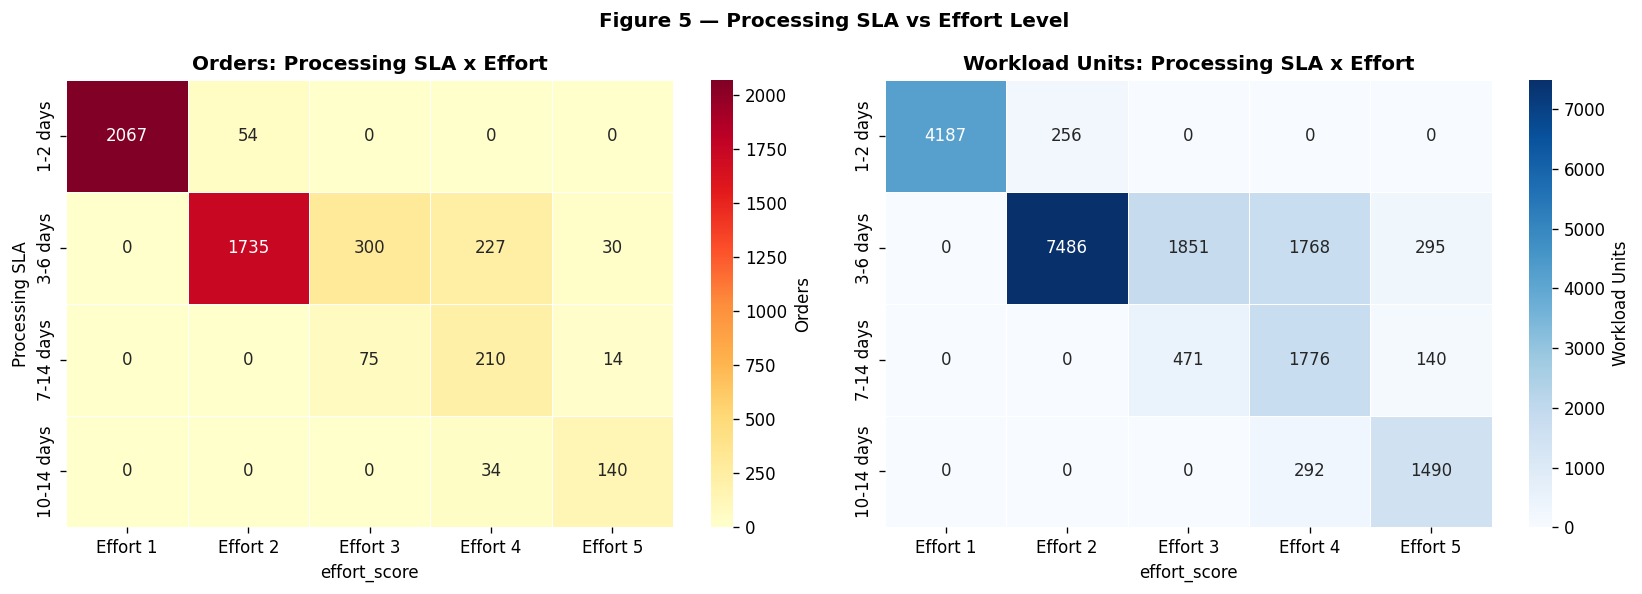

Tip: dark bottom-right cells = most complex, longest SLA — assign Senior Specialists.


In [6]:
PROC_ORDER = ['1-2 days', '3-6 days', '7-14 days', '10-14 days']
valid_labels = [p for p in PROC_ORDER if p in df['processing_label'].unique()]

proc_orders_pivot = (
    df.groupby(['processing_label', 'effort_score'])['order_id']
    .count().unstack(fill_value=0).reindex(valid_labels)
)
proc_wl_pivot = (
    df.groupby(['processing_label', 'effort_score'])['total_effort']
    .sum().unstack(fill_value=0).reindex(valid_labels)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(proc_orders_pivot, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5,
            xticklabels=[f'Effort {c}' for c in proc_orders_pivot.columns],
            cbar_kws={'label': 'Orders'})
axes[0].set_title('Orders: Processing SLA x Effort')
axes[0].set_ylabel('Processing SLA')

sns.heatmap(proc_wl_pivot, annot=True, fmt='.0f', cmap='Blues',
            ax=axes[1], linewidths=0.5,
            xticklabels=[f'Effort {c}' for c in proc_wl_pivot.columns],
            cbar_kws={'label': 'Workload Units'})
axes[1].set_title('Workload Units: Processing SLA x Effort')
axes[1].set_ylabel('')

plt.suptitle('Figure 5 — Processing SLA vs Effort Level', fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_processing_heatmap.png', bbox_inches='tight')
plt.show()
print('Tip: dark bottom-right cells = most complex, longest SLA — assign Senior Specialists.')

## 6. Express Order Pressure
Express orders bypass the standard queue and require **immediate capacity**. 
High-effort express orders are the hardest operational challenge.

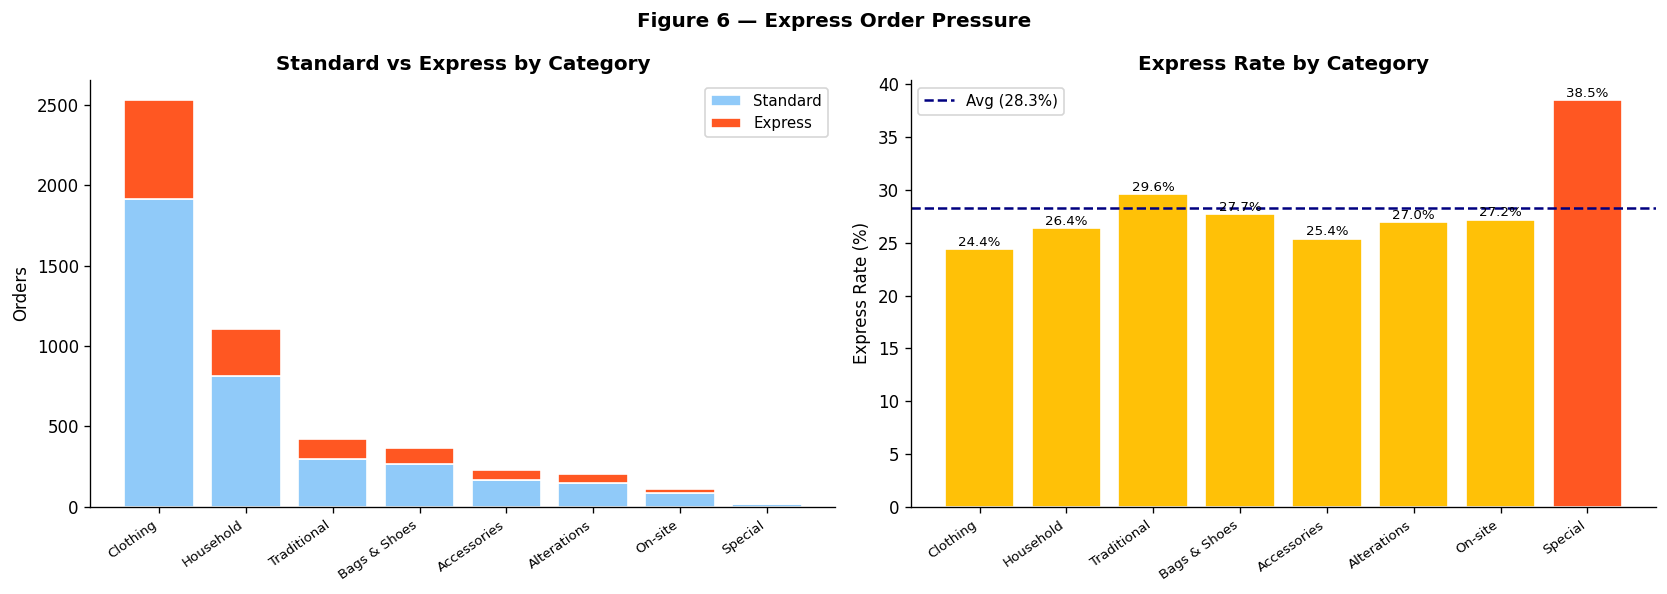

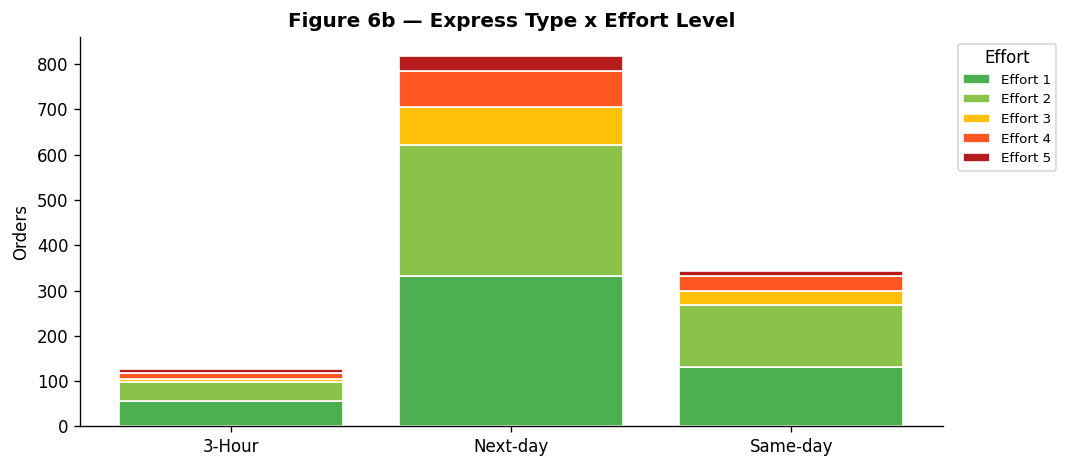

In [7]:
express_pivot = (
    df.assign(type=df['is_express'].map({True:'Express', False:'Standard'}))
    .groupby(['category', 'type'])['order_id'].count()
    .unstack(fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
    .assign(express_rate=lambda d: (d.get('Express', 0) / d['total'] * 100).round(1))
    .sort_values('total', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
ax = axes[0]
x = np.arange(len(express_pivot))
ax.bar(x, express_pivot.get('Standard', 0), label='Standard', color='#90CAF9', edgecolor='white')
ax.bar(x, express_pivot.get('Express', 0),  bottom=express_pivot.get('Standard', 0),
       label='Express', color='#FF5722', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(express_pivot.index, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Orders')
ax.set_title('Standard vs Express by Category')
ax.legend(fontsize=9)

# Express rate bar
ax2 = axes[1]
rate_colors = ['#FF5722' if r > 30 else '#FFC107' if r > 15 else '#4CAF50'
               for r in express_pivot['express_rate']]
bars = ax2.bar(express_pivot.index, express_pivot['express_rate'],
               color=rate_colors, edgecolor='white')
ax2.axhline(express_pivot['express_rate'].mean(), color='navy', linestyle='--',
            linewidth=1.5, label=f"Avg ({express_pivot['express_rate'].mean():.1f}%)")
for bar, v in zip(bars, express_pivot['express_rate']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{v}%', ha='center', fontsize=8)
ax2.set_xticklabels(express_pivot.index, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Express Rate (%)')
ax2.set_title('Express Rate by Category')
ax2.legend(fontsize=9)

plt.suptitle('Figure 6 — Express Order Pressure', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_express_pressure.png', bbox_inches='tight')
plt.show()

# Express x Effort breakdown
express_effort = (
    df[df['is_express']]
    .groupby(['express_type', 'effort_score'])['order_id'].count()
    .unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(express_effort))
for e in sorted(express_effort.columns):
    ax.bar(express_effort.index, express_effort[e], bottom=bottom,
           color=EFFORT_COLOURS[e], label=f'Effort {e}', edgecolor='white')
    bottom += express_effort[e].values
ax.set_ylabel('Orders')
ax.set_title('Figure 6b — Express Type x Effort Level', fontweight='bold')
ax.legend(title='Effort', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('fig6b_express_effort.png', bbox_inches='tight')
plt.show()

## 7. Weekly Workload Forecast
Aggregates total workload per week. Uses **1 technician per 80 workload units/week** as capacity baseline.

Avg weekly workload : 265 units
Peak weekly workload: 389 units (2024-W01)
Avg techs needed    : 3.8
Peak techs needed   : 5


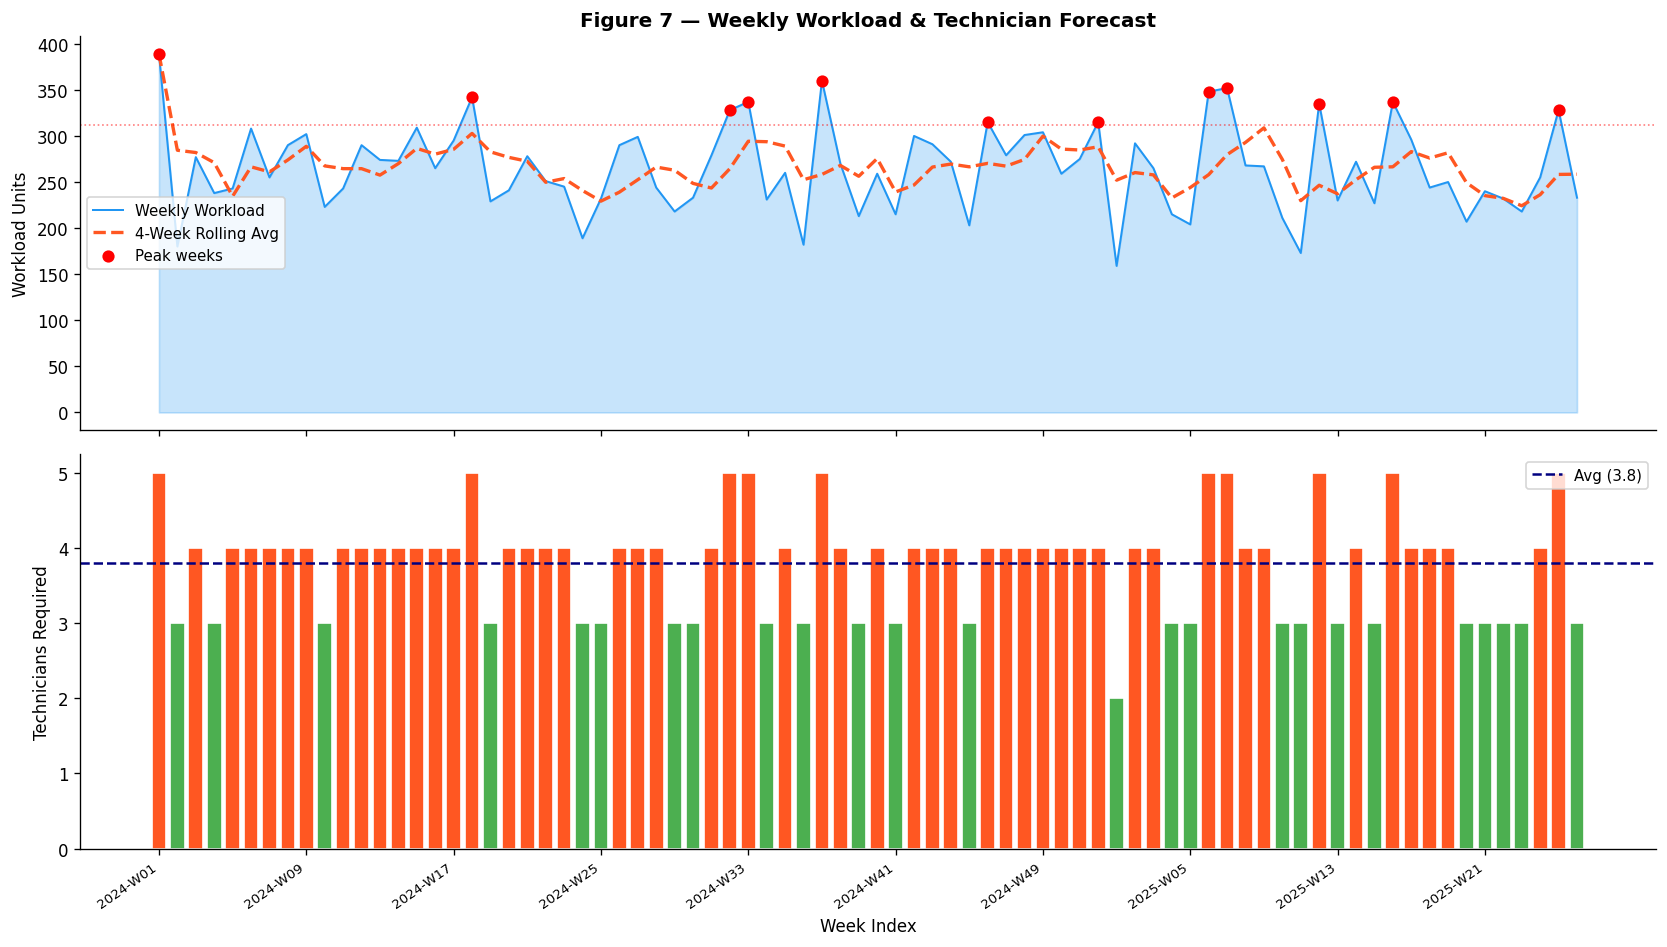

In [8]:
TECH_CAPACITY = 80  # workload units per technician per week

weekly = (
    df.groupby(['booking_year', 'booking_week'])
    .agg(
        orders         = ('order_id',       'count'),
        total_workload = ('total_effort',    'sum'),
        express_orders = ('is_express',      'sum'),
        revenue        = ('order_value_sgd', 'sum'),
    )
    .reset_index()
    .sort_values(['booking_year','booking_week'])
    .reset_index(drop=True)
)
weekly['period']           = weekly['booking_year'].astype(str) + '-W' + weekly['booking_week'].astype(str).str.zfill(2)
weekly['rolling4']         = weekly['total_workload'].rolling(4, min_periods=1).mean()
weekly['techs_needed']     = np.ceil(weekly['total_workload'] / TECH_CAPACITY).astype(int)

print(f'Avg weekly workload : {weekly.total_workload.mean():.0f} units')
print(f'Peak weekly workload: {weekly.total_workload.max():.0f} units ({weekly.loc[weekly.total_workload.idxmax(),"period"]})')
print(f'Avg techs needed    : {weekly.techs_needed.mean():.1f}')
print(f'Peak techs needed   : {weekly.techs_needed.max()}')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.fill_between(weekly.index, weekly['total_workload'], alpha=0.25, color='#2196F3')
ax.plot(weekly.index, weekly['total_workload'], color='#2196F3', linewidth=1.2, label='Weekly Workload')
ax.plot(weekly.index, weekly['rolling4'], color='#FF5722', linewidth=2, linestyle='--', label='4-Week Rolling Avg')
threshold = weekly['total_workload'].mean() + weekly['total_workload'].std()
peaks = weekly[weekly['total_workload'] > threshold]
ax.scatter(peaks.index, peaks['total_workload'], color='red', zorder=5, s=40, label='Peak weeks')
ax.axhline(threshold, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax.set_ylabel('Workload Units')
ax.set_title('Figure 7 — Weekly Workload & Technician Forecast', fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
bar_c = ['#FF5722' if t >= weekly['techs_needed'].quantile(0.75) else '#4CAF50' for t in weekly['techs_needed']]
ax2.bar(weekly.index, weekly['techs_needed'], color=bar_c, edgecolor='white', width=0.8)
ax2.axhline(weekly['techs_needed'].mean(), color='navy', linestyle='--', linewidth=1.5,
            label=f"Avg ({weekly['techs_needed'].mean():.1f})")
ax2.set_ylabel('Technicians Required')
ax2.set_xlabel('Week Index')
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.legend(fontsize=9)
tick_idx = weekly.index[::8]
ax2.set_xticks(tick_idx)
ax2.set_xticklabels(weekly.loc[tick_idx,'period'], rotation=35, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('fig7_weekly_forecast.png', bbox_inches='tight')
plt.show()

## 8. Day-of-Week Patterns
Identifies which days carry the most workload, highest complexity, and most express pressure.

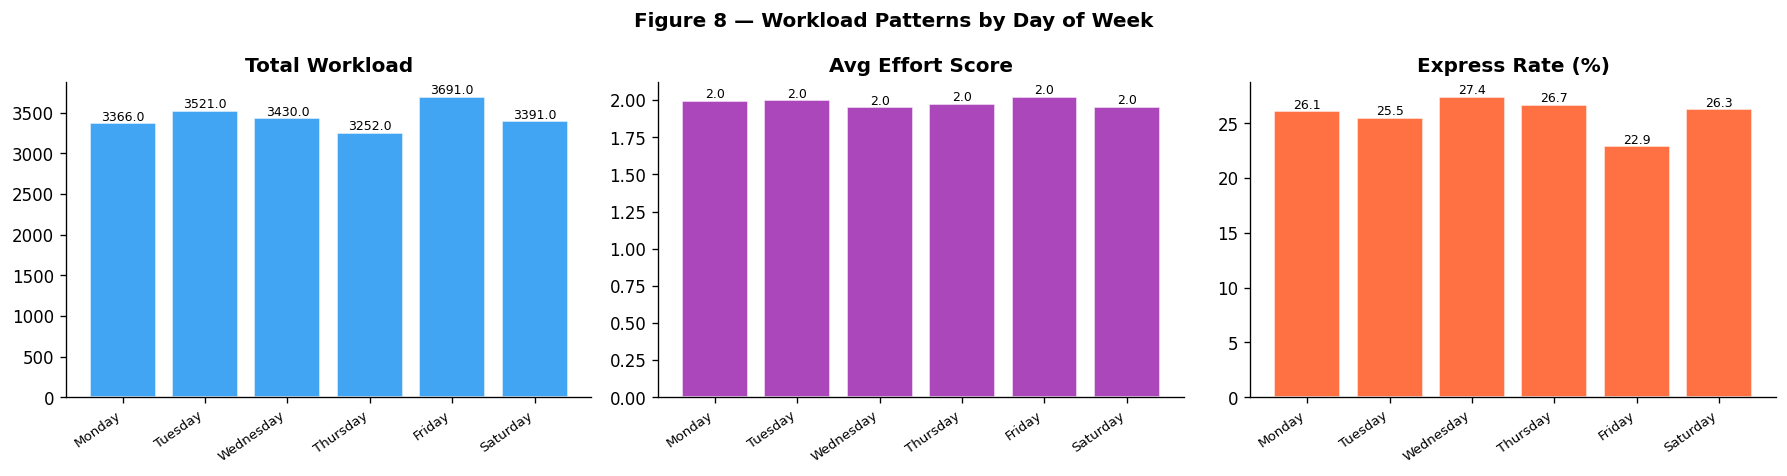

In [9]:
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = (
    df.groupby('booking_day_of_week')
    .agg(
        orders         = ('order_id',      'count'),
        total_workload = ('total_effort',  'sum'),
        avg_effort     = ('effort_score',  'mean'),
        express_orders = ('is_express',    'sum'),
    )
    .reindex([d for d in DOW_ORDER if d in df['booking_day_of_week'].unique()])
    .reset_index()
)
dow['express_rate'] = (dow['express_orders'] / dow['orders'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, colour in [
    (axes[0], 'total_workload', 'Total Workload',     '#2196F3'),
    (axes[1], 'avg_effort',     'Avg Effort Score',   '#9C27B0'),
    (axes[2], 'express_rate',   'Express Rate (%)',   '#FF5722'),
]:
    bars = ax.bar(dow['booking_day_of_week'], dow[col], color=colour, alpha=0.85, edgecolor='white')
    ax.set_title(title)
    ax.set_xticklabels(dow['booking_day_of_week'], rotation=35, ha='right', fontsize=8)
    for bar, v in zip(bars, dow[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'{v:.1f}', ha='center', fontsize=7.5)

plt.suptitle('Figure 8 — Workload Patterns by Day of Week', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_dow_patterns.png', bbox_inches='tight')
plt.show()

## 9. Technician Allocation
Maps orders to one of four technician types based on effort score and express flag, 
then shows which services route to which technician.

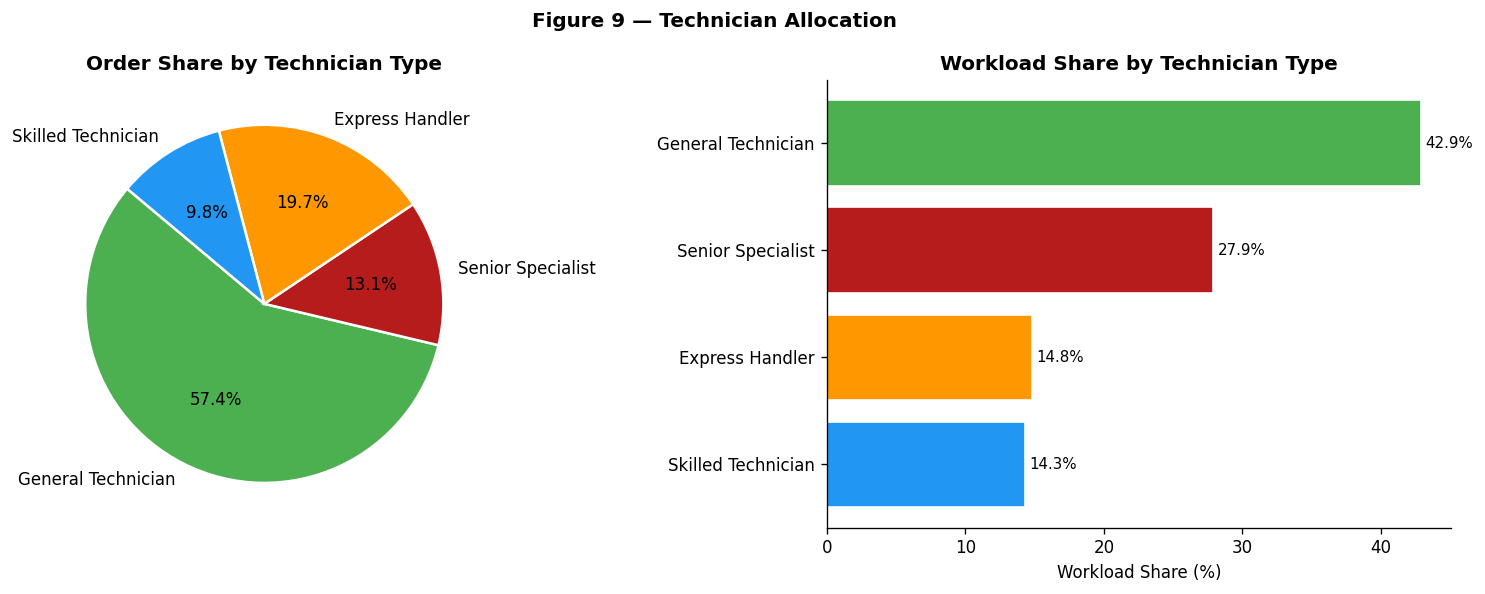

         tech_type  orders  total_workload   revenue  order_pct  workload_pct
General Technician    2870            8864 101543.03       57.4          42.9
 Senior Specialist     655            5761 125657.34       13.1          27.9
   Express Handler     986            3065  83932.42       19.7          14.8
Skilled Technician     489            2961  85855.28        9.8          14.3


In [10]:
tech_summary = (
    df.groupby('tech_type')
    .agg(
        orders         = ('order_id',       'count'),
        total_workload = ('total_effort',   'sum'),
        revenue        = ('order_value_sgd','sum'),
    )
    .reset_index()
    .sort_values('total_workload', ascending=False)
)
tech_summary['order_pct']    = (tech_summary['orders']         / tech_summary['orders'].sum()         * 100).round(1)
tech_summary['workload_pct'] = (tech_summary['total_workload'] / tech_summary['total_workload'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colours = [TECH_COLOURS[t] for t in tech_summary['tech_type']]

axes[0].pie(tech_summary['order_pct'], labels=tech_summary['tech_type'],
            autopct='%1.1f%%', colors=colours, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Order Share by Technician Type')

bars = axes[1].barh(tech_summary['tech_type'], tech_summary['workload_pct'], color=colours, edgecolor='white')
for bar, v in zip(bars, tech_summary['workload_pct']):
    axes[1].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{v}%', va='center', fontsize=9)
axes[1].set_xlabel('Workload Share (%)')
axes[1].set_title('Workload Share by Technician Type')
axes[1].invert_yaxis()

plt.suptitle('Figure 9 — Technician Allocation', fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_tech_allocation.png', bbox_inches='tight')
plt.show()

print(tech_summary.to_string(index=False))

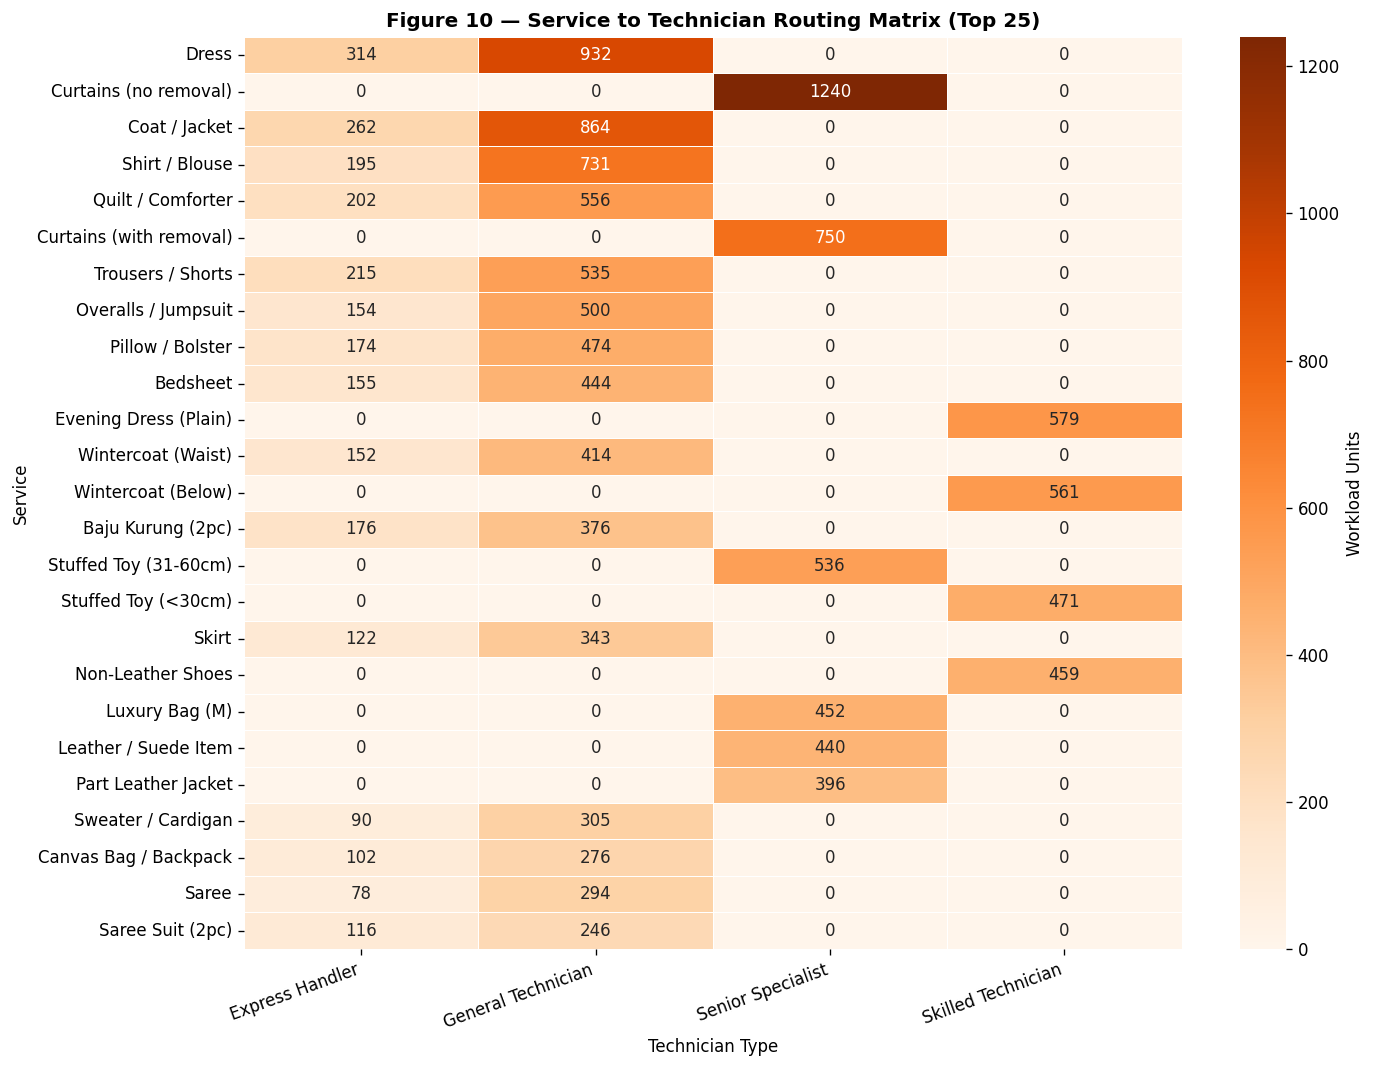

In [11]:
# Service routing matrix — which services go to which technician type
routing = (
    df.groupby(['service','tech_type'])['total_effort']
    .sum().unstack(fill_value=0)
)
top_svcs = svc_summary.head(25)['service'].tolist()
routing  = routing.reindex([s for s in top_svcs if s in routing.index])

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(routing, annot=True, fmt='.0f', cmap='Oranges',
            ax=ax, linewidths=0.4, cbar_kws={'label':'Workload Units'})
ax.set_title('Figure 10 — Service to Technician Routing Matrix (Top 25)', fontweight='bold')
ax.set_xlabel('Technician Type')
ax.set_ylabel('Service')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig10_routing_matrix.png', bbox_inches='tight')
plt.show()

## 10. Key Insights & Recommendations

In [12]:
print('=' * 60)
print('  ASTORIA — WORKFORCE PLANNING FINDINGS')
print('=' * 60)

low_effort_pct  = effort_summary[effort_summary['effort_score'] <= 2]['order_pct'].sum()
high_wl_pct     = effort_summary[effort_summary['effort_score'] >= 4]['workload_pct'].sum()
total_express   = df['is_express'].sum()
hi_exp_express  = df[df['is_express'] & (df['effort_score'] >= 4)].shape[0]
peak_dow        = dow.loc[dow['total_workload'].idxmax(), 'booking_day_of_week']
peak_techs      = weekly['techs_needed'].max()
avg_techs       = weekly['techs_needed'].mean()

print(f'\n1. EFFORT DISTRIBUTION')
print(f'   {low_effort_pct:.1f}% of orders are low effort (1-2) — OK for general staff')
print(f'   Effort 4-5 drives {high_wl_pct:.1f}% of total workload despite fewer orders')

print(f'\n2. TOP WORKLOAD SERVICES')
for _, r in svc_summary.head(5).iterrows():
    print(f'   {r["service"]:<30} workload: {r["total_workload"]:>6.0f}  effort: {r["effort_score"]}')

print(f'\n3. EXPRESS PRESSURE')
print(f'   {total_express:,} express orders ({total_express/len(df)*100:.1f}% of total)')
print(f'   {hi_exp_express} are high-effort (4-5) — need Senior Specialist immediately')

print(f'\n4. PEAK PERIODS')
print(f'   {peak_dow} is the highest workload day — schedule additional staff')
print(f'   Peak weeks need {peak_techs} technicians vs average of {avg_techs:.1f}')

print(f'\n5. STAFFING SPLIT')
for _, r in tech_summary.iterrows():
    print(f'   {r["tech_type"]:<22} {r["order_pct"]:>5.1f}% orders  {r["workload_pct"]:>5.1f}% workload')

print(f'\nRECOMMENDATIONS')
print('   1. Dedicate Senior Specialists to all Effort 4-5 services only')
print('   2. Create an Express Lane — reserve 1-2 staff for same-day / 3-hour orders')
print(f'   3. Ensure {peak_techs} technicians rostered on {peak_dow}s')
print('   4. Cross-train General Technicians on Effort 3 to reduce bottlenecks')
print('   5. Start 7-14 day SLA items early in the week to avoid end-of-week backlogs')
print('   6. Review pricing for categories with low revenue-per-workload-unit')
print('\n' + '=' * 60)

  ASTORIA — WORKFORCE PLANNING FINDINGS

1. EFFORT DISTRIBUTION
   77.1% of orders are low effort (1-2) — OK for general staff
   Effort 4-5 drives 27.9% of total workload despite fewer orders

2. TOP WORKLOAD SERVICES
   Dress                          workload:   1246  effort: 2
   Curtains (no removal)          workload:   1240  effort: 4
   Coat / Jacket                  workload:   1126  effort: 2
   Shirt / Blouse                 workload:    926  effort: 1
   Quilt / Comforter              workload:    758  effort: 2

3. EXPRESS PRESSURE
   1,290 express orders (25.8% of total)
   181 are high-effort (4-5) — need Senior Specialist immediately

4. PEAK PERIODS
   Friday is the highest workload day — schedule additional staff
   Peak weeks need 5 technicians vs average of 3.8

5. STAFFING SPLIT
   General Technician      57.4% orders   42.9% workload
   Senior Specialist       13.1% orders   27.9% workload
   Express Handler         19.7% orders   14.8% workload
   Skilled Technici